# Doubly periodic salt-finger convection using Dedalus 3

This notebook presents a Python code for simulating salt-finger convections in doubly periodic configuration using [Dedalus framework](https://dedalus-project.org/). Variables are non-dimensionalized based on the thermal diffusivity $\kappa_T$

\begin{equation}
T = \frac{T_*}{\Delta T}, \quad S = \frac{S_*}{\Delta S}, \quad t = \frac{t_*}{h^2/\kappa_T}, \quad \vec{u} = \frac{\vec{u}_*}{\kappa_T/h}, \quad p = \frac{p_*}{\kappa_T^2 \rho_{r*}/h^2}.
\end{equation}


In this work, I use a computational domain of $[L_x\times L_z]:=[2\pi/k_x\times 1]$ with $k_x$ representing the wavenumber in the horizontal direction. Fourier and Shebyshev spectral methods are used in the horizontal and vertical directions with $N_x = 128$ and $N_z = 128$, respectively. Dealiasing scaling factor is set by $3/2$.


The system is governed by (equation 2.2 in the reference)

\begin{equation}
\nabla\cdot \vec{u} = 0,
\end{equation}

\begin{equation}
\partial_t \vec{u}+\vec{u}\cdot\nabla\vec{u} = Pr\nabla^2\vec{u} -\nabla p + PrRa_{T}(T-R_{\rho}^{-1}S)\vec{e}_z,
\end{equation}

\begin{equation}
\partial_t T +\vec{u}\cdot\nabla T + w = \nabla^2 T,
\end{equation}

\begin{equation}
\partial_t S +\vec{u}\cdot\nabla S + w = \tau\nabla^2 S.
\end{equation}

where $\vec{u}$, $p$, and $\vec{e}_z$ are the fluid velocity, pressure, unit vector in the vertical. The governing parameters include the Prandtl number, the diffusivity ratio, the density ratio and the thermal Rayleigh number defined by

\begin{equation}
Ra := \frac{g\alpha\Delta T h^3}{\nu\kappa_T}, \quad Pr := \frac{\nu}{\kappa_T}, \quad \tau := \frac{\kappa_S}{\kappa_T}, \quad R_\rho := \frac{\alpha \Delta T}{\beta\Delta S},  
\end{equation}

where $\nu$ is the viscosity and $\kappa_S$ is the salinity diffusivity.

/home/ducubuntu/miniforge-pypy3/envs/dedalus3/lib/python3.12/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


2024-07-10 18:50:46,537 subsystems 0/1 INFO :: Building subproblem matrices 1/64 (~2%) Elapsed: 0s, Remaining: 14s, Rate: 4.5e+00/s
2024-07-10 18:50:47,393 subsystems 0/1 INFO :: Building subproblem matrices 7/64 (~11%) Elapsed: 1s, Remaining: 9s, Rate: 6.5e+00/s
2024-07-10 18:50:48,265 subsystems 0/1 INFO :: Building subproblem matrices 14/64 (~22%) Elapsed: 2s, Remaining: 7s, Rate: 7.2e+00/s
2024-07-10 18:50:49,164 subsystems 0/1 INFO :: Building subproblem matrices 21/64 (~33%) Elapsed: 3s, Remaining: 6s, Rate: 7.4e+00/s
2024-07-10 18:50:50,145 subsystems 0/1 INFO :: Building subproblem matrices 28/64 (~44%) Elapsed: 4s, Remaining: 5s, Rate: 7.3e+00/s
2024-07-10 18:50:51,038 subsystems 0/1 INFO :: Building subproblem matrices 35/64 (~55%) Elapsed: 5s, Remaining: 4s, Rate: 7.4e+00/s
2024-07-10 18:50:51,793 subsystems 0/1 INFO :: Building subproblem matrices 42/64 (~66%) Elapsed: 5s, Remaining: 3s, Rate: 7.7e+00/s
2024-07-10 18:50:52,745 subsystems 0/1 INFO :: Building subproblem matr

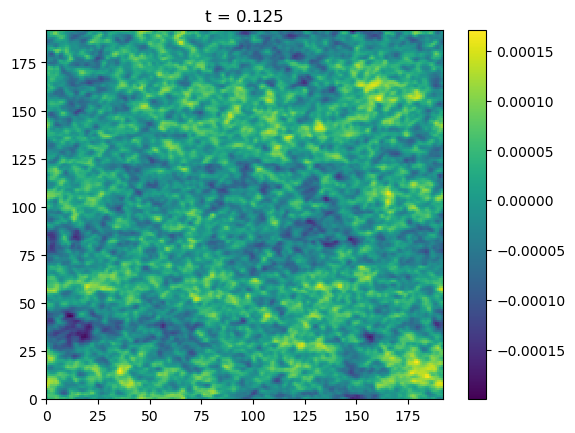

Completed iteration 101, time=7.769


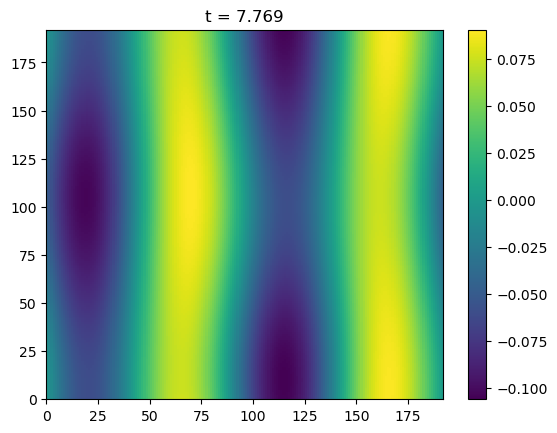

Completed iteration 201, time=8.481


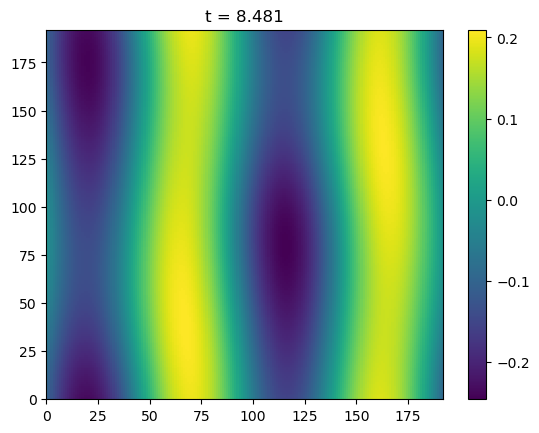

Completed iteration 301, time=8.855


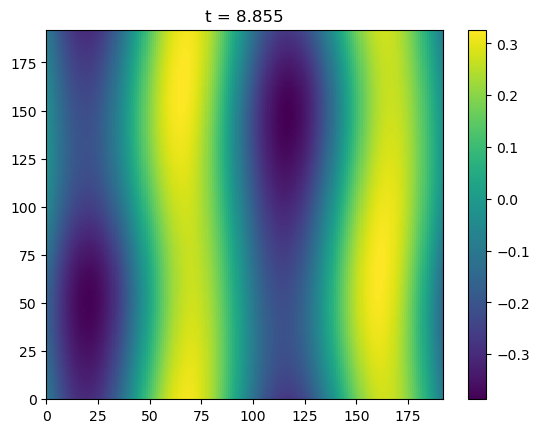

Completed iteration 401, time=9.112


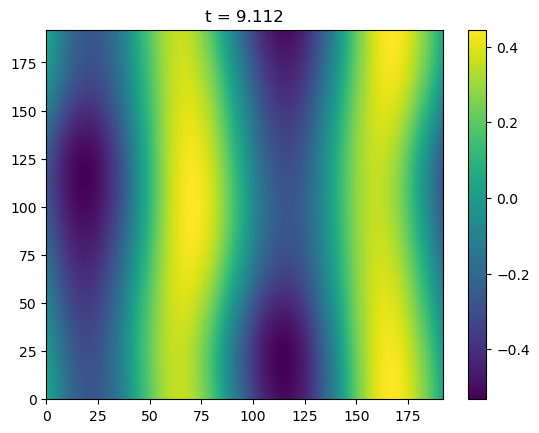

KeyboardInterrupt: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3
# Parameters
kx, kz = 8, 1 # wavenumber
Lx, Lz = 2*np.pi/kx, 1./kz    # computational domain
Nx, Nz = 128, 128       # number of points
dealias = 3/2           # scaling factor
Ra = 1e5    # Rayleigh number
Pr = 0.05     # Prandtl number
tau = 0.01 # diffusivity ratio = ks/kt
Rp = 40.0 # density ratio
# Bases
coords = d3.CartesianCoordinates('x','z')
dist = d3.Distributor(coords, dtype=np.float64)
# define the coordinate system
xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(0, Lx), dealias=dealias)
zbasis = d3.RealFourier(coords['z'], size=Nz, bounds=(0, Lz), dealias=dealias)
# define fields
p = dist.Field(name='p', bases=(xbasis,zbasis)) # create pressure field with scalar type
u = dist.VectorField(coords, name='u', bases=(xbasis,zbasis)) # create velocity field with vectoral type

sa = dist.Field(name='sa', bases=(xbasis,zbasis)) # create salinity field with scalar type
te = dist.Field(name='te', bases=(xbasis,zbasis)) # create temperature field with scalar type
# Substitutions
x, z = dist.local_grids(xbasis, zbasis) # get coordinate arrays in horizontal and vertical directions
ex, ez = coords.unit_vector_fields(dist) # get unit vectors in horizontal and vertical directions
# define velocity component in vertical direction
w = u @ ez

# create constant sub-field for incompressible flow condition's equation
tau_p = dist.Field(name='tau_p') 
# because this term is only a contant added to the equation, we don't need to instantiate it for bases system

grad_te = d3.grad(te) # First-order reduction

grad_sa = d3.grad(sa) # First-order reduction

grad_u = d3.grad(u) # First-order reduction

# First-order form: "lap(f)" becomes "div(grad_f)"
lap_u = d3.div(grad_u)
lap_te = d3.div(grad_te)
lap_sa = d3.div(grad_sa)
# Problem
problem = d3.IVP([p, tau_p, u, te, sa], namespace=locals())
# First-order form: "div(A)" becomes "trace(grad_A)"

# Continuity Equation
problem.add_equation("trace(grad_u) + tau_p = 0")
problem.add_equation("integ(p) = 0") # Pressure gauge
# equation 2
problem.add_equation("dt(u) - Pr*lap_u + grad(p) - Pr*Ra*(te-(1./Rp)*sa)*ez = - u@grad(u)")
# equation 3
problem.add_equation("dt(te) - lap_te + w = - u@grad(te)")
# equation 3
problem.add_equation("dt(sa) - tau*lap_sa + w = - u@grad(sa)")
stop_sim_time = 300 # Stopping criteria
timestepper = d3.RK443 # 3rd-order 4-stage DIRK+ERK scheme [Ascher 1997 sec 2.8] https://doi-org.ezproxy.lib.uconn.edu/10.1016/S0168-9274(97)00056-1
# timestepper = d3.RK222
# Solver
solver = problem.build_solver(timestepper)
solver.stop_sim_time = stop_sim_time
te.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise
# te['g'] *= z * (Lx - z) # Damp noise at walls
# te['g'] += z # Add linear background

sa.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise
# sa['g'] *= z * (Lx - z) # Damp noise at walls
# sa['g'] += z # Add linear background
# Analysis
import shutil, os
sim_name = 'Doubly_DNS'
if os.path.exists(sim_name):
    shutil.rmtree(sim_name) # remove the output directory and its previous contents

dataset = solver.evaluator.add_file_handler(sim_name, sim_dt=1.0, max_writes=1000)
dataset.add_task(te, name='temperature')
dataset.add_task(sa, name='salinity')
dataset.add_task(p, name='pressure')
dataset.add_task(u@ex, name='velocity_u')
dataset.add_task(u@ez, name='velocity_w')
dataset.add_task(-d3.div(d3.skew(u)), name='vorticity')

max_timestep = 0.125
# CFL
CFL = d3.CFL(solver, initial_dt=max_timestep, cadence=10, safety=0.5, threshold=0.05,
             max_change=1.5, min_change=0.5, max_dt=max_timestep)
CFL.add_velocity(u)
# Flow properties
# flow = d3.GlobalFlowProperty(solver, cadence=10)
# flow.add_property(np.sqrt(u@u)/nu, name='Re')


# Main loop
print('Starting main loop')
while solver.proceed:
    timestep = CFL.compute_timestep()
    solver.step(timestep)
    if (solver.iteration-1) % 250 == 0:
        print('Completed iteration {}, time={:.3f}'.format(solver.iteration, solver.sim_time))
        sa_plot = plt.pcolormesh(np.copy(sa['g']).transpose())
        plt.colorbar(sa_plot) 
        plt.title("t = {:.3f}".format(solver.sim_time))
        # plt.savefig("salinity{:.3f}.png".format(solver.sim_time), dpi=200)
        plt.show()